In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , SimpleRNN , GRU ,Embedding , LSTM , Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.datasets import imdb

In [2]:
(X_train,y_train) , (X_test,y_test) = imdb.load_data(num_words=10000)

In [3]:
maxlen = []
for i in X_train:
    length = len(i)
    maxlen.append(length)

print(max(maxlen))

2494


In [4]:
# pad the X_train and X_test
X_train = pad_sequences(X_train,maxlen=100)
X_test = pad_sequences(X_test,maxlen=100)

# **1. Deep RNN's**

## **1.1 Deep SimpleRNN**

In [5]:
model_1 = Sequential()

model_1.add(Embedding(10000 , 32 , input_length = 100))
model_1.add(SimpleRNN(5,return_sequences=True))
model_1.add(SimpleRNN(5))
model_1.add(Dense(1,activation='sigmoid'))
model_1.summary()

c:\Users\nasrullah\.conda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile the model
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
history = model_1.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 75ms/step - accuracy: 0.6055 - loss: 0.6496 - val_accuracy: 0.6266 - val_loss: 0.6524
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.7603 - loss: 0.5045 - val_accuracy: 0.7742 - val_loss: 0.4886
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.8613 - loss: 0.3520 - val_accuracy: 0.7822 - val_loss: 0.4939
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8961 - loss: 0.2771 - val_accuracy: 0.7834 - val_loss: 0.5019
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9144 - loss: 0.2368 - val_accuracy: 0.7840 - val_loss: 0.5149


## **1.2 Deep LSTM**

In [29]:
model_2 = Sequential()
model_2.add(Embedding(10000, 32, input_length=100))  
model_2.add(LSTM(5, return_sequences=True))
model_2.add(LSTM(5))
model_2.add(Dense(1, activation='sigmoid'))

model_2.summary()

c:\Users\nasrullah\.conda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile the model
model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [31]:
history_1 = model_2.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.7139 - loss: 0.5679 - val_accuracy: 0.8370 - val_loss: 0.3931
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 84ms/step - accuracy: 0.8898 - loss: 0.2907 - val_accuracy: 0.8434 - val_loss: 0.3722
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.9289 - loss: 0.1973 - val_accuracy: 0.8386 - val_loss: 0.3907
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.9560 - loss: 0.1387 - val_accuracy: 0.8328 - val_loss: 0.4558
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.9698 - loss: 0.1001 - val_accuracy: 0.8294 - val_loss: 0.5180


## **1.3 Deep GRU**

In [32]:
model_3 = Sequential()
model_3.add(Embedding(10000, 32, input_length=100))  
model_3.add(GRU(5, return_sequences=True))
model_3.add(GRU(5))
model_3.add(Dense(1, activation='sigmoid'))

model_3.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Compile the model
model_3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [34]:
history_2 = model_3.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.6463 - loss: 0.6053 - val_accuracy: 0.8332 - val_loss: 0.3887
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8806 - loss: 0.3038 - val_accuracy: 0.8408 - val_loss: 0.3727
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 72ms/step - accuracy: 0.9242 - loss: 0.2092 - val_accuracy: 0.8386 - val_loss: 0.3841
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.9547 - loss: 0.1417 - val_accuracy: 0.8304 - val_loss: 0.4585
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.9668 - loss: 0.1068 - val_accuracy: 0.8294 - val_loss: 0.4822


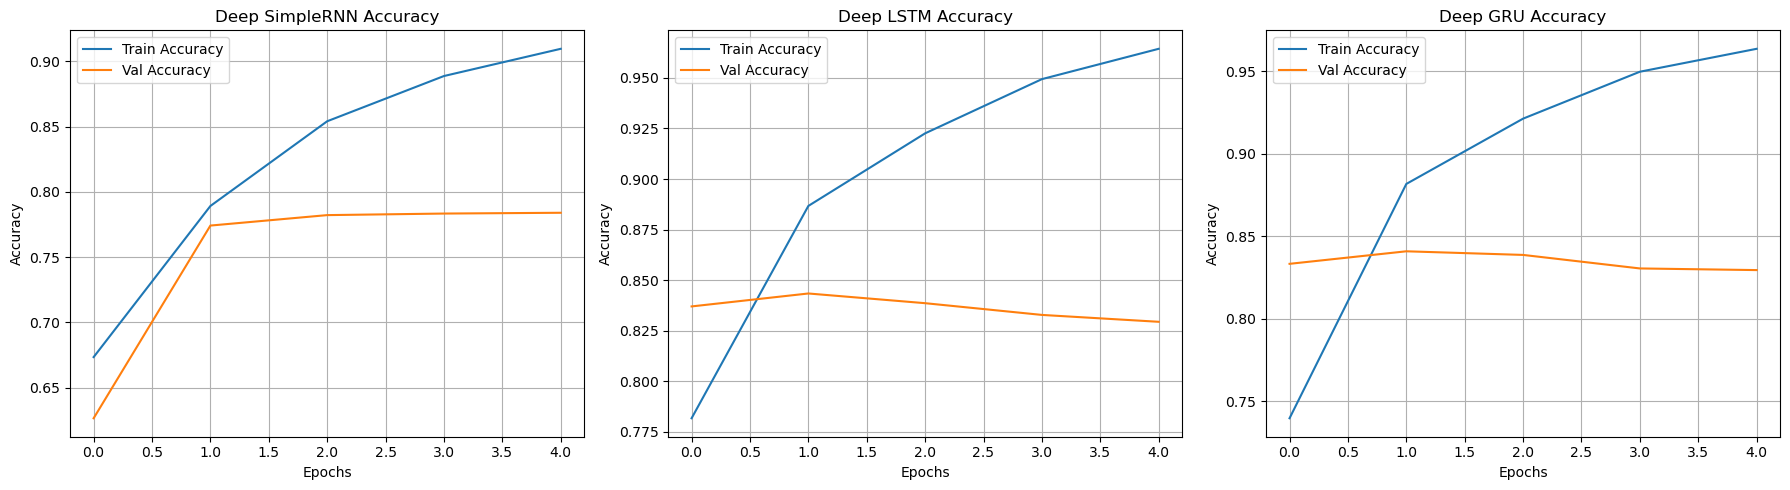

In [35]:
import matplotlib.pyplot as plt

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------- Model 1 --------
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Deep SimpleRNN Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# -------- Model 2 --------
axes[1].plot(history_1.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_1.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Deep LSTM Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# -------- Model 3 --------
axes[2].plot(history_2.history['accuracy'], label='Train Accuracy')
axes[2].plot(history_2.history['val_accuracy'], label='Val Accuracy')
axes[2].set_title('Deep GRU Accuracy')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


# **2. Bidirectional RNN's**

## **2.1 Bidirectional SimpleRNN**

In [36]:
# Create the model
model_4 = Sequential()
# Input layer
model_4.add(Embedding(input_dim=10000, output_dim=32, input_length=100))
# Bidirectional SimpleRNN layer
model_4.add(Bidirectional(SimpleRNN(32, return_sequences=False)))
# Output layer
model_4.add(Dense(1, activation='sigmoid'))

model_4.summary()

c:\Users\nasrullah\.conda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Compile the model
model_4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [38]:
# Fit the model
history_3 = model_4.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.5443 - loss: 0.6821 - val_accuracy: 0.7462 - val_loss: 0.5187
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8283 - loss: 0.3881 - val_accuracy: 0.7960 - val_loss: 0.4829
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9457 - loss: 0.1552 - val_accuracy: 0.7818 - val_loss: 0.5553
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.9910 - loss: 0.0396 - val_accuracy: 0.7924 - val_loss: 0.6387
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9991 - loss: 0.0091 - val_accuracy: 0.8038 - val_loss: 0.7296


## **2.2 Bidirectional LSTM**

In [39]:
# Create the model
model_5 = Sequential()
# Input layer
model_5.add(Embedding(input_dim=10000, output_dim=32, input_length=100))
# Bidirectional LSTM layer
model_5.add(Bidirectional(LSTM(32, return_sequences=False)))
# Output layer
model_5.add(Dense(1, activation='sigmoid'))

model_5.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Compile the model
model_5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
# Fit the model
history_4 = model_5.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.6873 - loss: 0.5497 - val_accuracy: 0.8426 - val_loss: 0.3647
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8968 - loss: 0.2663 - val_accuracy: 0.8406 - val_loss: 0.3558
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.9334 - loss: 0.1837 - val_accuracy: 0.8422 - val_loss: 0.4168
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.9586 - loss: 0.1189 - val_accuracy: 0.8332 - val_loss: 0.4603
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.9751 - loss: 0.0756 - val_accuracy: 0.8322 - val_loss: 0.5855


## **2.3 Bidirectional GRU**

In [42]:
# Create the model
model_6 = Sequential()
# Input layer
model_6.add(Embedding(input_dim=10000, output_dim=32, input_length=100))
# Bidirectional GRU layer
model_6.add(Bidirectional(GRU(32, return_sequences=False)))
# Output layer
model_6.add(Dense(1, activation='sigmoid'))

model_6.summary()

c:\Users\nasrullah\.conda\envs\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the model
model_6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [44]:
# Fit the model
history_5 = model_6.fit(X_train,y_train,epochs=5,batch_size=32,validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.6629 - loss: 0.5726 - val_accuracy: 0.8394 - val_loss: 0.4000
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.8941 - loss: 0.2662 - val_accuracy: 0.8460 - val_loss: 0.3515
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.9311 - loss: 0.1823 - val_accuracy: 0.8396 - val_loss: 0.4089
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.9572 - loss: 0.1216 - val_accuracy: 0.8364 - val_loss: 0.4677
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.9751 - loss: 0.0721 - val_accuracy: 0.8348 - val_loss: 0.6032


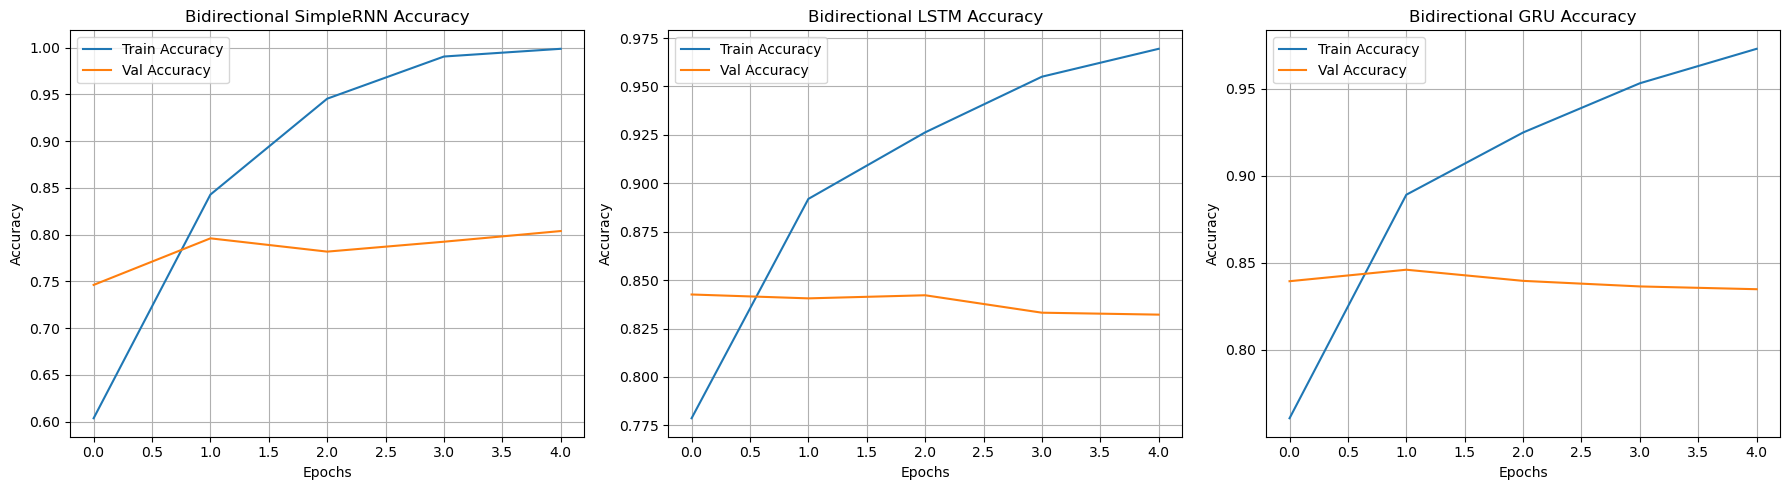

In [45]:
import matplotlib.pyplot as plt

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------- Model 4 --------
axes[0].plot(history_3.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_3.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Bidirectional SimpleRNN Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# -------- Model 5 --------
axes[1].plot(history_4.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_4.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Bidirectional LSTM Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# -------- Model 6 --------
axes[2].plot(history_5.history['accuracy'], label='Train Accuracy')
axes[2].plot(history_5.history['val_accuracy'], label='Val Accuracy')
axes[2].set_title('Bidirectional GRU Accuracy')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
